# Agent 13 â€” Reporting

**What this notebook does:**  
Generates all the charts and tables needed for the presentation slides and the one-page factsheet.

**How to present this to investors:**  
> *Our reporting agent automatically generates the portfolio factsheet, benchmark comparison charts, ESG profile, and sector allocation â€” all from the same underlying data, ensuring consistency between what we show and what we calculated.*

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import glob
from datetime import date

TODAY = str(date.today())
REPORT_DIR = "../outputs/reports"

# Load portfolio
port_files = sorted(glob.glob("../outputs/portfolio/final_portfolio_*.csv"))
univ_files = sorted(glob.glob("../outputs/portfolio/universe_scores_*.csv"))

if not port_files:
    raise FileNotFoundError("Run notebook 04 first.")

portfolio = pd.read_csv(port_files[-1])
universe  = pd.read_csv(univ_files[-1])

print(f"Portfolio: {len(portfolio)} holdings")
print(f"Universe:  {len(universe)} companies")

Portfolio: 20 holdings
Universe:  164 companies


## Chart 1 â€” Portfolio weights (horizontal bar chart)

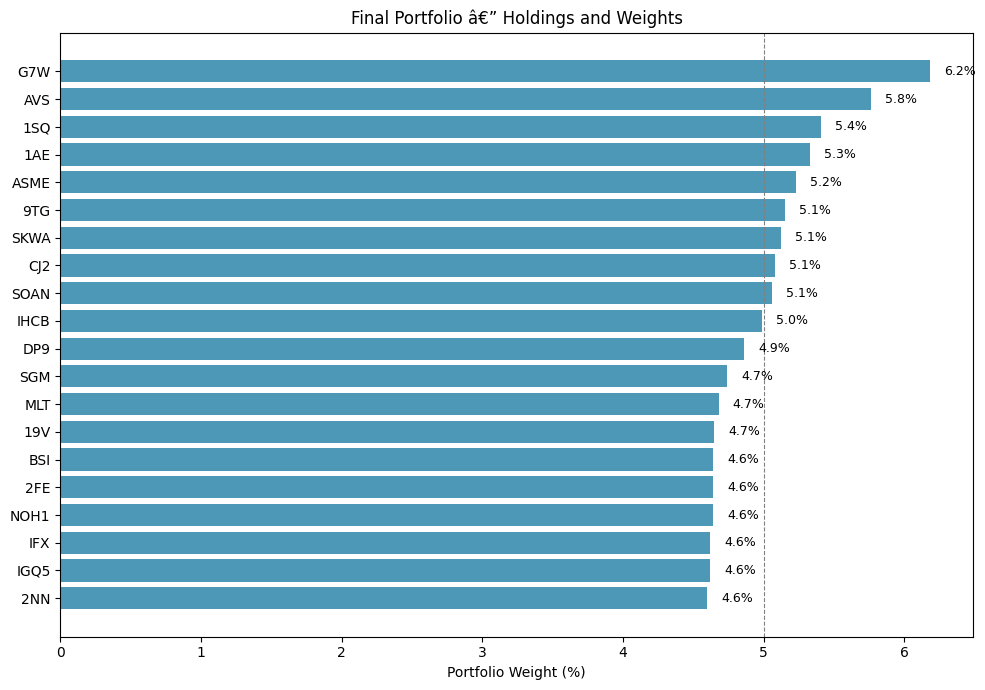

Chart 1 saved.


In [2]:
TICKER_COL = "ticker"

fig, ax = plt.subplots(figsize=(10, 7))
sorted_port = portfolio.sort_values("weight")

bars = ax.barh(sorted_port[TICKER_COL], sorted_port["weight"] * 100, color="#2E86AB", alpha=0.85)
ax.set_xlabel("Portfolio Weight (%)")
ax.set_title("Final Portfolio â€” Holdings and Weights")
ax.axvline(5, color="grey", linestyle="--", linewidth=0.8, label="5% line")

for bar, val in zip(bars, sorted_port["weight"] * 100):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/portfolio_weights.png", dpi=150)
plt.show()
print("Chart 1 saved.")

## Chart 2 â€” ESG Score: Portfolio vs. Universe

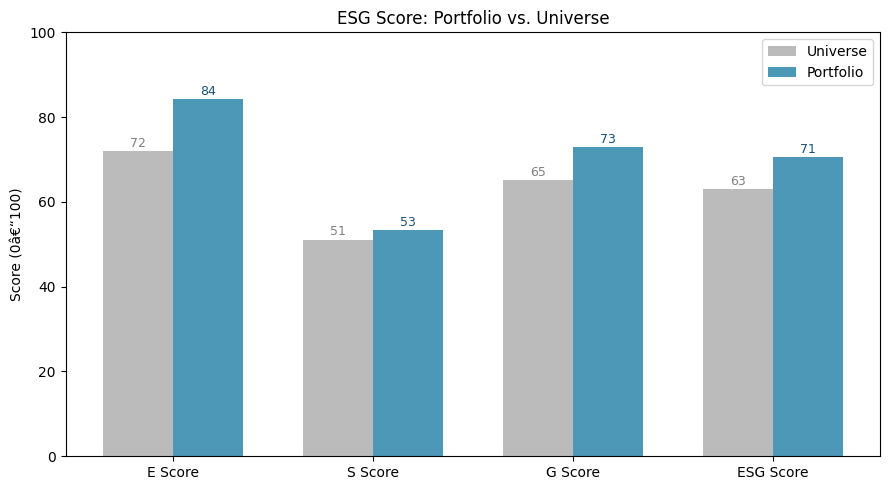

Chart 2 saved.


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

categories = ["E Score", "S Score", "G Score", "ESG Score"]
port_vals  = [portfolio["E_score"].mean(), portfolio["S_score"].mean(),
              portfolio["G_score"].mean(), portfolio["ESG_score"].mean()]
univ_vals  = [universe["E_score"].mean(), universe["S_score"].mean(),
              universe["G_score"].mean(), universe["ESG_score"].mean()]

x = np.arange(len(categories))
w = 0.35

ax.bar(x - w/2, univ_vals, w, label="Universe", color="#AAAAAA", alpha=0.8)
ax.bar(x + w/2, port_vals, w, label="Portfolio", color="#2E86AB", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Score (0â€“100)")
ax.set_title("ESG Score: Portfolio vs. Universe")
ax.set_ylim(0, 100)
ax.legend()

for xi, (uv, pv) in enumerate(zip(univ_vals, port_vals)):
    ax.text(xi - w/2, uv + 1, f"{uv:.0f}", ha="center", fontsize=9, color="grey")
    ax.text(xi + w/2, pv + 1, f"{pv:.0f}", ha="center", fontsize=9, color="#1a5276")

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/esg_comparison.png", dpi=150)
plt.show()
print("Chart 2 saved.")

## Chart 3 â€” Sector allocation (pie chart)

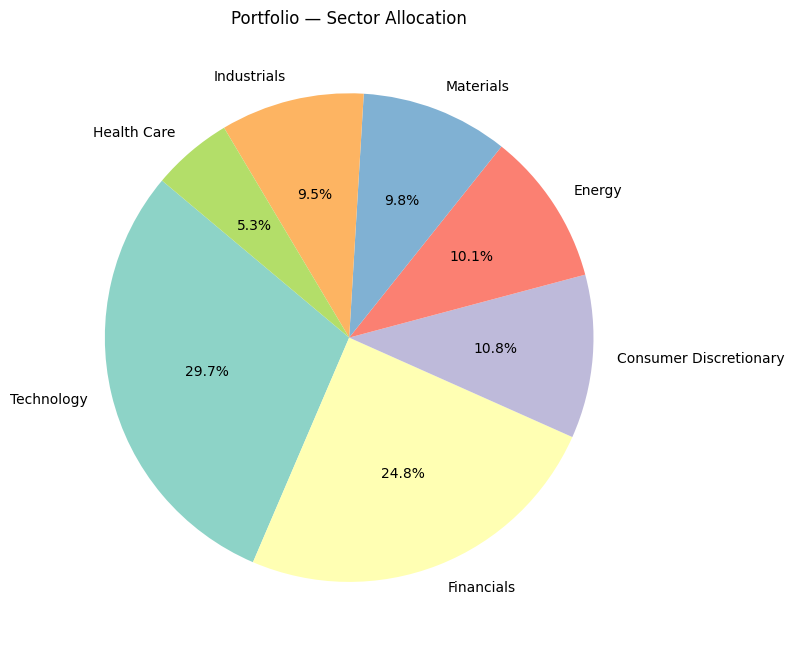

Chart 3 saved.

Sectors represented: 7 (minimum required: 5)
  Technology                     29.7%
  Financials                     24.8%
  Consumer Discretionary         10.8%
  Energy                         10.1%
  Materials                      9.8%
  Industrials                    9.5%
  Health Care                    5.3%


In [4]:
# Sector column: portfolio uses bics_sector (Bloomberg sector from master dataset)
SECTOR_COL = "bics_sector" if "bics_sector" in portfolio.columns else "sector"

if SECTOR_COL in portfolio.columns:
    sector_weights = portfolio.groupby(SECTOR_COL)["weight"].sum().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 8))
    wedges, texts, autotexts = ax.pie(
        sector_weights,
        labels=sector_weights.index,
        autopct="%1.1f%%",
        startangle=140,
        colors=plt.cm.Set3.colors
    )
    ax.set_title("Portfolio — Sector Allocation")
    plt.tight_layout()
    plt.savefig(f"{REPORT_DIR}/sector_allocation.png", dpi=150)
    plt.show()
    print("Chart 3 saved.")
    print(f"\nSectors represented: {len(sector_weights)} (minimum required: 5)")
    for sec, w in sector_weights.items():
        print(f"  {sec:<30} {w:.1%}")
else:
    print(f"No sector column found. Columns available: {list(portfolio.columns)}")

## Table â€” Top 5 Holdings Summary

This goes directly onto the factsheet and presentation Slide 7.

In [5]:
display_cols = [c for c in [TICKER_COL, "idBbGlobalCompanyName", "weight",
                             "ESG_score", "sharpe_ratio", "nature_risk_tier", "composite_score"]
                if c in portfolio.columns]

top5 = portfolio.nlargest(5, "weight")[display_cols].copy()
top5["weight"] = top5["weight"].map("{:.1%}".format)
print("Top 5 Holdings:")
top5

Top 5 Holdings:


,ticker,idBbGlobalCompanyName,weight,ESG_score,sharpe_ratio,nature_risk_tier,composite_score
0,G7W,Games Workshop Group PLC,6.2%,76.22,1.123,Low,80.42
1,AVS,ASM International NV,5.8%,75.87,0.923,Low,74.95
2,1SQ,Swissquote Group Holding SA,5.4%,75.58,0.880,Low,70.33
3,1AE,Argenx SE,5.3%,62.38,1.064,Low,69.31
4,ASME,ASML Holding NV,5.2%,66.45,0.872,Low,68.04


## Print: Factsheet Summary Block

Copy this text block into your one-page factsheet document.

In [6]:
# WACI calculation (Weighted Average Carbon Intensity)
waci_col   = "carbon_intensity"
ci_src_col = "ci_source"

if waci_col in portfolio.columns and portfolio[waci_col].notna().any():
    ci_col = portfolio[ci_src_col] if ci_src_col in portfolio.columns else pd.Series("unknown", index=portfolio.index)
    reported_mask = (ci_col == "bloomberg_calc")
    waci_full     = (pd.to_numeric(portfolio[waci_col], errors="coerce").fillna(0) * portfolio["weight"]).sum()
    n_reported    = int(reported_mask.sum())
    waci_str = f"{waci_full:.1f} tCO₂e/€m rev ({n_reported}/{len(portfolio)} bloomberg_calc, rest sector-median)"
else:
    waci_str = "N/A — run Agent 5/6 to add carbon_intensity column"

weighted_esg    = (pd.to_numeric(portfolio["ESG_score"],    errors="coerce") * portfolio["weight"]).sum()
weighted_sharpe = (pd.to_numeric(portfolio["sharpe_ratio"], errors="coerce") * portfolio["weight"]).sum()
universe_esg    = pd.to_numeric(universe["ESG_score"], errors="coerce").mean()
max_weight      = portfolio["weight"].max()
sectors_in_port = portfolio["bics_sector"].nunique() if "bics_sector" in portfolio.columns else "N/A"

print("=" * 62)
print("   PORTFOLIO FACTSHEET — KEY METRICS")
print("=" * 62)
print(f"  Date:                    {TODAY}")
print(f"  Number of Holdings:      {len(portfolio)}")
print(f"  Sectors Represented:     {sectors_in_port} (minimum: 5)")
print(f"  Weighted ESG Score:      {weighted_esg:.1f} / 100")
print(f"  Universe ESG Score:      {universe_esg:.1f} / 100  (full universe avg)")
print(f"  ESG Uplift vs Universe:  {weighted_esg - universe_esg:+.1f} points")
print(f"  Weighted Sharpe Ratio:   {weighted_sharpe:.3f}")
print(f"  WACI:                    {waci_str}")
print(f"  Max Single Weight:       {max_weight:.1%}")
print("=" * 62)

   PORTFOLIO FACTSHEET — KEY METRICS
  Date:                    2026-05-14
  Number of Holdings:      20
  Sectors Represented:     7 (minimum: 5)
  Weighted ESG Score:      70.8 / 100
  Universe ESG Score:      63.0 / 100  (full universe avg)
  ESG Uplift vs Universe:  +7.8 points
  Weighted Sharpe Ratio:   0.776
  WACI:                    431.6 tCO₂e/€m rev (2/20 bloomberg_calc, rest sector-median)
  Max Single Weight:       6.2%


## âœ… All done!

All charts saved to `outputs/reports/`. Your pipeline is complete:

| Notebook | Agent | Status |
|----------|-------|--------|
| 01_data_ingestion | Data Ingestion Agent | âœ… |
| 02_financial_analysis | Financial Analysis Agent | âœ… |
| 03_esg_scoring | ESG Scoring Agent | âœ… |
| 04_portfolio_construction | Portfolio Construction Agent | âœ… |
| 05_reporting | Reporting Agent | âœ… |

**Remaining work (outside notebooks):**
- Claude Projects RAG â†’ greenwashing 8-Test (RAG Operator)
- n8n.cloud orchestration diagram (Pipeline Operator)
- Written report sections (all)